# `data-gen` Showcase & Tutorial Notebook

This notebook serves as an interactive tutorial for the `data-gen` package. It demonstrates how to initialize the synthesizers, feed them real-world datasets, generate synthetic clones, and visualize the generated data alongside the original inputs.

We will cover the four primary domains supported by the package:
1. **Tabular Data**
2. **Text Data**
3. **Image Data**
4. **Time Series Data**


In [ ]:
# Setup and Imports
import pandas as pd
import numpy as np

# Base utilities
from data_gen.core.utils import set_seed
set_seed(42) # Ensure reproducible results

## 1. Tabular Data Generation
We use the `GaussianCopulaSynthesizer` to model mathematical relationships from an original DataFrame and generate a synthetic clone.

In [2]:
from data_gen.tabular.gaussian_copula import GaussianCopulaSynthesizer
from data_gen.tabular.evaluation import evaluate_tabular
from pathlib import Path

# 1. Load real dataset
tabular_data_path = Path("tabular/data.xlsx")
real_tabular = pd.read_excel(tabular_data_path)

# 2. Initialize and fit the synthesizer
tabular_synth = GaussianCopulaSynthesizer()
tabular_synth.fit(real_tabular)

# 3. Generate synthetic data
synthetic_tabular = tabular_synth.generate(num_samples=500)

metrics = evaluate_tabular(real_tabular, synthetic_tabular)
print(f"Tabular Evaluation Metrics: {metrics}")


/ws/Programs/PF/data-gen/venv/lib/python3.12/site-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/ws/Programs/PF/data-gen/venv/lib/python3.12/site-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Tabular Evaluation Metrics: {'ks_complement': {'depth': 0.9613333333333334, 'seed': 0.43400000000000005, 'test_acc': 0.48844444444444446, 'test_loss': 0.3646666666666667, 'final_val_acc': 0.48844444444444446, 'training_time': 0.8071111111111111, 'barren_plateau': 0.0}, 'cs_test': {'approach': 0.990536}, 'column_shapes': {'approach': 0.990536, 'depth': 0.9932457515172449, 'seed': 0.4959084192385752, 'test_acc': 0.9419674540696878, 'test_loss': 0.9555149164586734, 'final_val_acc': 0.9418999011649409, 'training_time': 0.9896557455319079, 'barren_plateau': 1.0}, 'correlation_similarity': 0.7486427810720345, 'overall_score': 0.5870198645635595}


In [3]:
# Compare Tabular Results
import IPython.display as display

print("\n--- Real Tabular Data (First 5 rows) ---")
display.display(real_tabular.head())

print("\n--- Synthetic Tabular Data (First 5 rows) ---")
display.display(synthetic_tabular.head())


--- Real Tabular Data (First 5 rows) ---


,approach,depth,seed,test_acc,test_loss,final_val_acc,training_time,barren_plateau
0,baseline,4,101112,0.750,0.540047,0.750,1544.904917,False
1,baseline,4,123,0.730,0.551726,0.730,1565.959832,False
2,baseline,4,42,0.760,0.517600,0.760,1583.029523,False
3,baseline,4,456,0.755,0.546280,0.755,1536.039392,False
4,baseline,4,789,0.705,0.582032,0.705,1549.940420,False



--- Synthetic Tabular Data (First 5 rows) ---


,approach,depth,seed,test_acc,test_loss,final_val_acc,training_time,barren_plateau
0,layerwise,4,145,0.7950,0.490570,0.794999,1065.964258,False
1,layerwise,8,1354,0.7777,0.627736,0.777671,4353.290906,False
2,local_cost,4,74643,0.7947,0.490603,0.794663,1384.523458,False
3,local_cost,4,126,0.7950,0.490570,0.795000,2317.884410,False
4,local_cost,4,90455,0.7947,0.490570,0.794702,1590.151915,False


## 2. Text Data Generation
We showcase two approaches from the package:
1. **Text Pattern Generation** using `MarkovTextGenerator`: Requires zero heavy ML dependencies. It learns n-gram patterns from a real corpus to construct new plausible synthetic text.
2. **Text AI Generation** using `TransformerTextGenerator`: Uses a pre-trained deep learning transformer model for zero-shot text generation given stylistic contexts.

In [4]:
from data_gen.text.markov import MarkovTextGenerator
from data_gen.text.transformer import TransformerTextGenerator
import re
import os
from pathlib import Path
import warnings

# Suppress verbose warnings from transformers for a clean notebook output
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
warnings.filterwarnings('ignore')
import transformers
transformers.logging.set_verbosity_error()

# Load real corpus (Sherlock Holmes), skipping Gutenberg legal header
text_data_path = Path("text/data.txt")
with open(text_data_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

# The actual story begins around line 70, let's grab a chunk of it
actual_text = " ".join([l.strip() for l in lines[75:300] if l.strip()])
mock_corpus = [s.strip() for s in re.split(r'[.!?]+', actual_text) if len(s.strip()) > 30]

print("--- Real Text Samples (from Corpus) ---")
for i, txt in enumerate(mock_corpus[:3]):
    print(f"Real {i+1}: {txt}")

# --- 1. Text Pattern Generation (Markov) ---
print("\n--- 1. Text Pattern Generation (MarkovTextGenerator) ---")
markov_gen = MarkovTextGenerator(order=2)
markov_gen.fit(mock_corpus)

synthetic_markov_text = markov_gen.generate(num_samples=3)
for i, txt in enumerate(synthetic_markov_text):
    print(f"Markov Synthetic {i+1}: {txt}")

# --- 2. Text AI Generation (Transformer) ---
print("\n--- 2. Text AI Generation (TransformerTextGenerator) ---")
try:
    transformer_gen = TransformerTextGenerator()
    # We feed the real data as context into the transformer, just like we fitted the markov generator
    context_data = "\n".join(mock_corpus[:15])
    transformer_gen.prepare(corpus=context_data)
    
    # We let the transformer use its context without strong external prompts so styling emerges naturally
    synthetic_ai_text = transformer_gen.generate(
        num_samples=3,
        instructions="Please write a sentence continuing the story based on the provided text.",
        max_length=50
    )
    
    for i, txt in enumerate(synthetic_ai_text):
         print(f"Transformer Synthetic {i+1}: {txt}")
except Exception as e:
    print(f"Skipping Transformer generation due to missing dependencies/resources - Error: {e}")


--- Real Text Samples (from Corpus) ---
Real 1: One night--it was on the twentieth of March, 1888--I was returning from a journey to a patient (for I had now returned to civil practice), when my way led me through Baker Street
Real 2: As I passed the well-remembered door, which must always be associated in my mind with my wooing, and with the dark incidents of the Study in Scarlet, I was seized with a keen desire to see Holmes again, and to know how he was employing his extraordinary powers
Real 3: His rooms were brilliantly lit, and, even as I looked up, I saw his tall, spare figure pass twice in a dark silhouette against the blind

--- 1. Text Pattern Generation (MarkovTextGenerator) ---
Markov Synthetic 1: One night--it was on the right side of his face, extending down past the cheekbones, a black mark of nitrate of silver upon his right forefinger, and a gasogene in the passage, paused immediately outside the door Then there was a loud and authoritative tap A man entered who could 

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 1077.70it/s]


Transformer Synthetic 1: As I sat down in the armchair, Holmes leaned back in his chair, his eyes fixed intently on mine, and began to speak in a low, soothing voice, as if to calm the storm raging within me.
Transformer Synthetic 2: As I sat down in the armchair, Holmes began to explain the nature of the case, his eyes sparkling with intensity as he delved into the intricacies of the problem.
Transformer Synthetic 3: As I sat down in the armchair, Holmes leaned back in his chair, his eyes never leaving mine, and I could sense the weight of his thoughts, the burden of his years, and the burden of his secrets.


## 3. Image Data Generation (Augmentation)
The `ImageAugmentor` uses Albumentations under the hood to efficiently mutate image datasets across customizable 'intensity' profiles.

Initializing ImageAugmentor (Medium Intensity)...


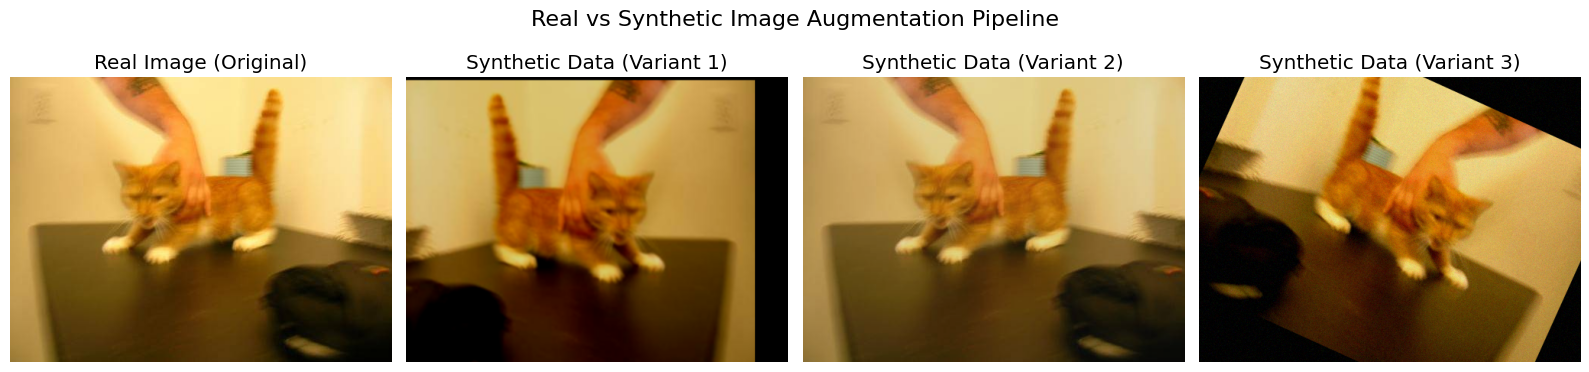

In [ ]:
from data_gen.image.augmentor import ImageAugmentor
from PIL import Image
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

print("Initializing ImageAugmentor (Medium Intensity)...")
aug = ImageAugmentor(intensity="medium")

# Load real images from the data directory
image_data_path = Path("image/data")
aug.prepare(image_data_path)

# Pick exactly one base image and augment it so we can easily compare
aug._images = [aug._images[0]] # Just use the first image for a clearer demo of augmentation
synthetic_images = aug.generate(num_samples=3, seed=84)

# Plotting the results
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Show the real image
axes[0].imshow(np.array(aug._images[0]))
axes[0].set_title("Real Image (Original)")
axes[0].axis('off')

# Show the synthetically augmented variants
for i, s_img in enumerate(synthetic_images):
    axes[i+1].imshow(s_img)
    axes[i+1].set_title(f"Synthetic Data (Variant {i+1})")
    axes[i+1].axis('off')
    
plt.suptitle("Real vs Synthetic Image Augmentation Pipeline", fontsize=16)
plt.tight_layout()
plt.show()

## 4. Time Series Generation
The `TimeSeriesSynthesizer` learns complex longitudinal distributions using a Probabilistic AutoRegressive (PAR) model.

In [6]:
from data_gen.timeseries.par import TimeSeriesSynthesizer
from pathlib import Path
import IPython.display as display

# Load real longitudinal dataset
ts_data_path = Path("timeseries/data.csv")
real_ts = pd.read_csv(ts_data_path, parse_dates=['date'])

# Reduce data for demonstration speed 
real_ts['store_dept'] = real_ts['store'].astype(str) + '_' + real_ts['department'].astype(str)
subset_keys = real_ts['store_dept'].unique()[:2]
real_ts_subset = real_ts[real_ts['store_dept'].isin(subset_keys)].copy()
real_ts_subset = real_ts_subset[['store_dept', 'date', 'weekly_sales', 'temperature_c']]

try:
    ts_synth = TimeSeriesSynthesizer()
    ts_synth.fit(real_ts_subset, sequence_key='store_dept', context_columns=[])
    synthetic_ts = ts_synth.generate(num_samples=2)

    print("\n--- Real Time Series Data ---")
    display.display(real_ts_subset.head())
    
    print("\n--- Synthetic Time Series Data ---")
    display.display(synthetic_ts.head())
    
except Exception as e:
    print(f"Skipping Full TS generation demo due to error: {e}")


--- Real Time Series Data ---


,store_dept,date,weekly_sales,temperature_c
0,1_1,2020-02-05,24924.50,5.727778
1,1_1,2020-03-05,21827.90,8.055556
2,1_1,2020-04-02,57258.43,16.816667
3,1_1,2020-05-07,17413.94,22.527778
4,1_1,2020-06-04,17558.09,27.050000



--- Synthetic Time Series Data ---


,store_dept,date,weekly_sales,temperature_c
0,sdv-id-RrHouG,2020-05-06,36131.59,12.188267
1,sdv-id-RrHouG,2020-04-12,19327.03,15.421747
2,sdv-id-RrHouG,2020-04-23,31461.59,20.352631
3,sdv-id-RrHouG,2020-06-03,20074.98,22.783411
4,sdv-id-RrHouG,2020-06-23,20575.42,24.755804
